In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

## Constants

In [197]:
# Constants
G = 1
c = 1
M = 0.5
# Schwarzchild Radius
rs = 2*G*M/(c**2)

## Initial Conditions

In [200]:
# Coordinates
theta0 = np.pi/2
phi0 = np.pi/2
t0 = 0
r0 = 3*M
eps = 0
# Parameters
L = np.sqrt(27)*M
E = 1

## Calculation of Initial Velocities

In [202]:
v_t0 = E/(c**2) * 1/(1-rs/r0)
v_p0 = L/(r0**2)
v_th0 = 0
v_r0 = -1*np.sqrt((eps + (v_t0**2)*(1-rs/r0) - (r0**2)*((v_th0**2) + ((np.sin(theta0)**2)*(v_p0**2))))*(1-rs/r0))
print(v_r0, v_t0, v_p0, v_th0)

nan 2.9999999999999996 1.1547005383792515 0


/var/folders/94/3f1zrhrn73b93rkt4k4nkywc0000gn/T/ipykernel_14727/2195151567.py:4: RuntimeWarning: invalid value encountered in sqrt
  v_r0 = -1*np.sqrt((eps + (v_t0**2)*(1-rs/r0) - (r0**2)*((v_th0**2) + ((np.sin(theta0)**2)*(v_p0**2))))*(1-rs/r0))


## Christoffel Symbols

In [5]:
def christoffel(a, b, c, r, theta): # 0 = t, 1 = r, 2 = theta, 3 = phi
    if(a == 1 and b == 0 and c == 0):
        return M*(r-2*M)/(r**3)
    if(a == 1 and b == 1 and c == 1):
        return -M/(r*(r-2*M))
    if(a == 1 and b == 2 and c == 2):
        return -(r-2*M)
    if(a == 1 and b == 3 and c == 3):
        return -(r-2*M)*(np.sin(theta)**2)
    if(a == 0 and b == 1 and c == 0):
        return M/(r*(r-2*M))
    if(a == 2 and b == 1 and c == 2):
        return 1/r
    if(a == 2 and b == 3 and c == 3):
        return -np.sin(theta) * np.cos(theta)
    if(a == 3 and b == 1 and c == 3):
        return 1/r
    if(a == 3 and b == 2 and c == 3):
        return np.cos(theta)/np.sin(theta)

## Solver Function

In [6]:
def solve(l, r):
    t, r, theta, phi, v_t, v_r, v_th, v_p = r

    # DEs for positional coordinates
    f_t = v_t
    f_r = v_r
    f_th = v_th
    f_p = v_p

    # DEs for velocities
    f_v_t = -1*(2*christoffel(0,1,0,r,theta)*v_r*v_t)
    f_v_r = -1*(christoffel(1,0,0,r,theta)*v_t*v_t + christoffel(1,1,1,r,theta)*v_r*v_r + 
                christoffel(1,2,2,r,theta)*v_th*v_th + christoffel(1,3,3,r,theta)*v_p*v_p)
    f_v_th = -1*(2*christoffel(2,1,2,r,theta)*v_r*v_th + christoffel(2,3,3,r,theta)*v_p*v_p)
    f_v_p = -1*(2*christoffel(3,1,3,r,theta)*v_r*v_p + 2*christoffel(3,2,3,r,theta)*v_th*v_p)

    # REMEMBER! Christoffel Symbols are symmetric and both their symmetric terms have to be added.

    return f_t, f_r, f_th, f_p, f_v_t, f_v_r, f_v_th, f_v_p

## Solving the given metric

In [177]:
sol = solve_ivp(solve, (0,1000), (t0, r0, theta0, phi0, v_t0, v_r0, v_th0, v_p0), 
                t_eval=np.linspace(0,1000,10000), rtol=1e-8, atol=1e-10)

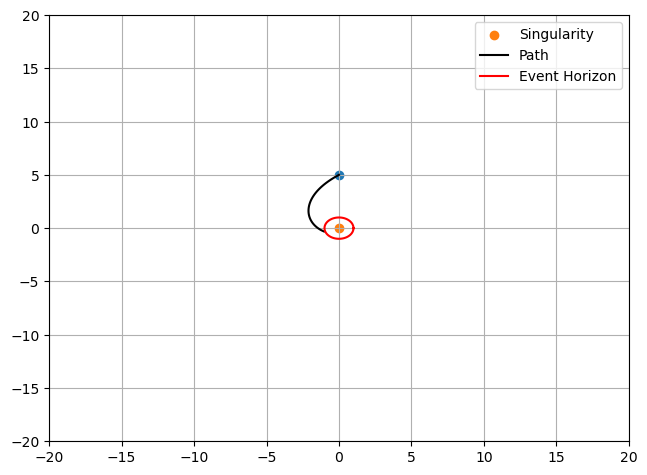

In [180]:
x = sol.y[1]*np.cos(sol.y[3])
y = sol.y[1]*np.sin(sol.y[3])

plt.scatter(x[0],y[0])
plt.scatter(0,0, label = "Singularity")
plt.plot(x,y, color ="black", label = "Path")

theta_c = np.linspace(0, 2*np.pi, 100)
x_c = rs * np.cos(theta_c)
y_c = rs * np.sin(theta_c)
plt.plot(x_c, y_c, color="red", label ="Event Horizon")

plt.tight_layout()
plt.legend()
plt.grid()
plt.xlim((-20,20))
plt.ylim((-20,20))
plt.show()

In [159]:
sol.y[2]

array([1.04719755, 1.04720547, 1.04722971, 1.04727105, 1.0473303 ,
       1.04740829, 1.04750594, 1.04762416, 1.04776396, 1.04792637,
       1.04811247, 1.04832343, 1.04856045, 1.04882481, 1.04911786,
       1.04944101, 1.04979577, 1.05018372, 1.05060652, 1.05106595,
       1.05156387, 1.05210225, 1.05268319, 1.05330889, 1.0539817 ,
       1.05470411, 1.05547874, 1.05630839, 1.05719604, 1.05814483,
       1.05915812, 1.06023947, 1.06139268, 1.0626218 , 1.06393112,
       1.06532526, 1.06680912, 1.06838794, 1.07006732, 1.07185328,
       1.07375222, 1.07577104, 1.07791713, 1.08019841, 1.0826234 ,
       1.08520129, 1.08794195, 1.09085603, 1.09395503, 1.09725137,
       1.1007585 , 1.10449097, 1.10846458, 1.1126965 , 1.1172054 ,
       1.12201161, 1.12713735, 1.13260689, 1.1384468 , 1.1446863 ,
       1.15135746, 1.15849566, 1.16613999, 1.17433376, 1.18312508,
       1.19256754, 1.20272109, 1.213653  , 1.22543902, 1.23816492,
       1.25192823, 1.26684049, 1.28303006, 1.30064571, 1.31986

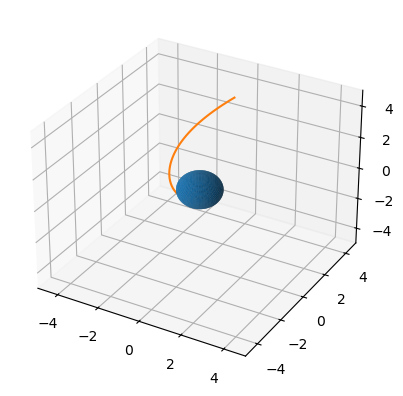

In [179]:
from mpl_toolkits import mplot3d
fig = plt.figure()
ax = plt.axes(projection="3d")


u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)

radius = 1
x = radius * np.outer(np.cos(u), np.sin(v))
y = radius * np.outer(np.sin(u), np.sin(v))
z = radius * np.outer(np.ones(np.size(u)), np.cos(v))
sphere = ax.plot_surface(x, y, z, edgecolor='none', alpha=1)


x = sol.y[1]*np.cos(sol.y[3])*np.sin(sol.y[2])
y = sol.y[1]*np.sin(sol.y[3])*np.sin(sol.y[2])
z = sol.y[1]*np.cos(sol.y[2])

ax.set_xlim((-r0,r0))
ax.set_ylim((-r0,r0))
ax.set_zlim((-r0,r0))

ax.plot3D(x,y,z)
plt.show()